# CFC plot (Linear regression + global)

In [1]:
from ana_utils import *
import warnings
warnings.filterwarnings("ignore")

d:\ProgramFiles\Anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
d:\ProgramFiles\Anaconda3\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
d:\ProgramFiles\Anaconda3\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


Subjects from Excel:  616
SUB_ID_LIST: list, format is like this:  sub-286 , and total length of SUB_ID_LIST = 371 {'NCI': 176, 'aMCI': 116, 'naMCI': 79}


In [2]:
csv_dir = f"{PROJ_HOME}/results/lr_glob_lm_cfc"
output_dir = f"{PROJ_HOME}/results/1_global_CFC"
os.makedirs(output_dir, exist_ok=True)
print("Output dir:", output_dir)

# Convert colors in PAL4 and CM_ARR_COLOR to hex format
colors_hex = [mcolors.to_hex(color) for color in PAL4]
cm_arr_hex = [mcolors.to_hex(color) for color in CM_ARR_COLOR]

# Print the assigned variables for verification
print("Colors (hex):", colors_hex)
print("CM Array Colors (hex):", cm_arr_hex)
print("Language Model Labels:", LM_LAB)

Output dir: D:/Shanghaitec/PROJECT/CSVD_neo/results/1_global_CFC
Colors (hex): ['#fa7f6f', '#ffbe7a', '#82b0d2']
CM Array Colors (hex): ['#9a7bb7', '#9a7bb7', '#7b8cb7', '#7b8cb7', '#999999']
Language Model Labels: ['wb', 'int', 'wmh']


In [3]:
# Merge CFC data for five LMs
merged_data = pd.concat(
    [
        pd.read_csv(f"{csv_dir}/lrcms-cfc_{lm_lab}.csv").assign(lm=lm_lab)
        for lm_lab in LM_LAB
    ],
    ignore_index=True,
)

# Calculate merged_diff_df (INT - WMH for each pid and Group)
int_sub_df = merged_data[merged_data.lm == LM_LAB[1]].set_index(["pid", "Group"])
wmh_sub_df = merged_data[merged_data.lm == LM_LAB[2]].set_index(["pid", "Group"])

merged_diff_df = (int_sub_df[CM_LAB_ARR] - wmh_sub_df[CM_LAB_ARR]).reset_index()

# ANOVA for global model's rsq

In [4]:
comp_res = []
anova_res = pg_anova(merged_data[merged_data.lm==LM_LAB[0]], col_name="rsq", factors="Group")
print("Mixed ANOVA Result:")
print(anova_res[0])
print(anova_res[2:])
# Append results to the comparison results list
comp_res.append(
    {
        "CM": "Model",
        "Tractography": 'All',
        "F(2, 354)": anova_res[2],
        "P_Group": anova_res[3],
        f"P_1": add_statistic_annotation(anova_res[4][0]),
        f"P_2": add_statistic_annotation(anova_res[4][1]),
        f"P_3": add_statistic_annotation(anova_res[4][2]),
        f"g_1": anova_res[5][0],
        f"g_2": anova_res[5][1],
        f"g_3": anova_res[5][2],
    }
)
print(anova_res[0])
display(anova_res[1])
# Save comparison results to a CSV file
pd.DataFrame(comp_res).to_csv(f"{output_dir}/global_CFC_model_R2_comparison.csv")

Mixed ANOVA Result:
  Source  ddof1  ddof2      F  p-unc    np2
0  Group      2    354  6.104  0.002  0.033
(6.104, 0.002, [0.312, 0.001, 0.209], [-0.223, -0.418, -0.216], [-0.005, -0.011, -0.006])
  Source  ddof1  ddof2      F  p-unc    np2
0  Group      2    354  6.104  0.002  0.033


,A,B,mean(A),mean(B),diff,se,T,df,pval,cohen
0,aMCI,naMCI,0.078,0.084,-0.005,0.003,-1.462,150.069,0.312,-0.223
1,aMCI,NCI,0.078,0.090,-0.011,0.003,-3.659,272.990,0.001,-0.418
2,naMCI,NCI,0.084,0.090,-0.006,0.004,-1.697,177.444,0.209,-0.216


## INT and WMH 

In [5]:
# Two-way ANOVA between int_subtbl and wmh_subtbl
int_wmh_df = pd.concat(
    [
        int_sub_df.reset_index().assign(lm="int"),
        wmh_sub_df.reset_index().assign(lm="wmh"),
    ],
    ignore_index=True,
)

In [6]:
mixed_result = pg_mix_anova(
    int_wmh_df)
display(
mixed_result[0])

Significant Group effect detected.

Post-hoc comparisons (averaged across INT-tractography):


,A,B,mean(A),mean(B),diff,se,T,df,pval,cohen
0,NCI,aMCI,0.084,0.075,0.009,0.003,3.107,266.914,0.006,0.360
1,NCI,naMCI,0.084,0.078,0.005,0.004,1.558,169.350,0.267,0.202
2,aMCI,naMCI,0.075,0.078,-0.004,0.003,-1.097,152.403,0.517,-0.167



Post-hoc comparisons (averaged across WMH-tractography):


,A,B,mean(A),mean(B),diff,se,T,df,pval,cohen
0,NCI,aMCI,0.054,0.049,0.005,0.003,1.682,264.735,0.214,0.196
1,NCI,naMCI,0.054,0.055,-0.001,0.004,-0.154,165.554,0.987,-0.020
2,aMCI,naMCI,0.049,0.055,-0.006,0.004,-1.585,151.995,0.255,-0.241


,Source,SS,DF1,DF2,MS,F,p-unc,ng2,eps
0,Group,0.007,2,354,0.004,3.192,0.042,0.014,NaN
1,lm,0.130,1,354,0.130,486.683,0.000,0.212,1.0
2,Interaction,0.001,2,354,0.001,2.144,0.119,0.002,NaN


## Swarmplot for global R2

AttributeError: 'list' object has no attribute 'values'

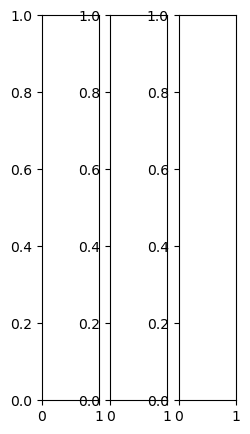

In [7]:
# Set the y-axis limit and create subplots
ylim = 0.28
fig, axes = plt.subplots(nrows=1, ncols=len(LM_LAB), figsize=(2.5, 5))
axes = axes.flatten()
comp_res = []

# Iterate through each language model label
for i, lm_lab in enumerate(LM_LAB):
    ax = axes[i]
    lr_res_tbl = merged_data[merged_data.lm == lm_lab]
    
    anova_res = pg_anova(lr_res_tbl)
    posthoc_p = anova_res[5].values[1:]

    # Plot swarmplot
    plot_ax_swarmplot(lr_res_tbl, ax, i, x="Group", y="rsq", ylim=0.24, swarmsize=3)
    ax.set_ylabel("")
    ax.set_yticks(np.round(np.linspace(0, ylim, 5), 2))
    ax.set_yticklabels(ax.get_yticks(), rotation=90)

    # Adjust axis appearance
    if i > 0:
        ax.spines["left"].set_color("None")
        ax.set(yticks=[], ylabel="")
    if ax.get_ylim()[0] > ax.get_ylim()[1]:
        ax.invert_yaxis()
    sns.despine(trim=True, ax=ax)

    # Add significance lines and annotations
    sig_line_xs = [(1 / 6, 1 / 2), (1 / 6, 5 / 6), (1 / 2, 5 / 6)]
    for j, p_val in enumerate(posthoc_p):
        if p_group < 0.05 and p_val < 0.05:
            ax.text(
                0.5 + 0.5 * j,
                ylim * (0.9 - j * 0.1),
                get_stats_sig(p_val),
                ha="center",
            )
            ax.axhline(
                ylim * (0.9 - j * 0.1),
                xmin=sig_line_xs[j][0],
                xmax=sig_line_xs[j][1],
                color="black",
                linestyle="-",
                lw=1,
                zorder=1,
            )


# Adjust layout and save the figure
plt.tight_layout()
plt.savefig(f"{output_dir}/global_CFC_model_R2_comparison.svg", bbox_inches="tight", dpi=300)

display(pd.DataFrame(comp_res))

In [ ]:
group_comparisons = {}
for group in DISGROUPS:
    df_group = int_wmh_tbl[int_wmh_tbl['Group'] == group]
    
    # 配对t检验
    pairwise_result = pg.pairwise_ttests(
        data=df_group,
        dv='rsq',
        within='lm',
        subject='pid',
        parametric=True
    )
    group_comparisons[group] = pairwise_result
    print(pairwise_result)
    
    # 计算描述性统计
    wmh_mean = df_group[df_group['lm'] == 'WMH']['rsq'].mean()
    int_mean = df_group[df_group['lm'] == 'INT']['rsq'].mean()
    print(f"WMH均值: {wmh_mean:.4f}, INT均值: {int_mean:.4f}, 差值: {int_mean-wmh_mean:.4f}")

  Contrast    A    B  Paired  Parametric          T    dof alternative  \
0       lm  int  wmh    True        True  12.241694  107.0   two-sided   

          p-unc       BF10    hedges  
0  4.506018e-22  1.003e+19  1.147127  
WMH均值: nan, INT均值: nan, 差值: nan
  Contrast    A    B  Paired  Parametric         T   dof alternative  \
0       lm  int  wmh    True        True  8.668779  77.0   two-sided   

          p-unc       BF10    hedges  
0  5.219944e-13  1.522e+10  0.922231  
WMH均值: nan, INT均值: nan, 差值: nan
  Contrast    A    B  Paired  Parametric          T    dof alternative  \
0       lm  int  wmh    True        True  16.339999  170.0   two-sided   

          p-unc       BF10    hedges  
0  1.094160e-36  2.408e+33  1.027468  
WMH均值: nan, INT均值: nan, 差值: nan


# ANOVA for each CM and LM

In [ ]:
comp_res = []
for cm_lab in CM_LAB_ARR:
    
    anova_res = pg_anova(merged_data[merged_data.lm==LM_LAB[0]], col_name=cm_lab, factors="Group")
    print("Mixed ANOVA Result:")
    print(anova_res[0])
    print(anova_res[2:])
    # Append results to the comparison results list
    comp_res.append(
        {
            "CM": cm_lab,
            "Tractography": 'All',
            "F(2, 354)": anova_res[2],
            "P_Group": anova_res[3],
            f"P_1": add_statistic_annotation(anova_res[4][0]),
            f"P_2": add_statistic_annotation(anova_res[4][1]),
            f"P_3": add_statistic_annotation(anova_res[4][2]),
            f"g_1": anova_res[5][0],
            f"g_2": anova_res[5][1],
            f"g_3": anova_res[5][2],
        }
    )
    print(anova_res[0])
    display(anova_res[1])
    # Save comparison results to a CSV file
pd.DataFrame(comp_res).to_csv(f"{output_dir}/global_CFC_dominance_comparison.csv")

Mixed ANOVA Result:
  Source  ddof1  ddof2      F  p-unc    np2
0  Group      2    354  6.058  0.003  0.033
(6.058, 0.003, [0.636, 0.003, 0.096], [-0.134, -0.408, -0.28], [-0.001, -0.002, -0.002])
  Source  ddof1  ddof2      F  p-unc    np2
0  Group      2    354  6.058  0.003  0.033


,A,B,mean(A),mean(B),diff,se,T,df,pval,cohen
0,aMCI,naMCI,0.021,0.022,-0.001,0.001,-0.908,169.180,0.636,-0.134
1,aMCI,NCI,0.021,0.024,-0.002,0.001,-3.334,230.665,0.003,-0.408
2,naMCI,NCI,0.022,0.024,-0.002,0.001,-2.085,156.314,0.096,-0.280


Mixed ANOVA Result:
  Source  ddof1  ddof2      F  p-unc   np2
0  Group      2    354  5.525  0.004  0.03
(5.525, 0.004, [0.984, 0.01, 0.031], [-0.025, -0.355, -0.332], [-0.0, -0.002, -0.002])
  Source  ddof1  ddof2      F  p-unc   np2
0  Group      2    354  5.525  0.004  0.03


,A,B,mean(A),mean(B),diff,se,T,df,pval,cohen
0,aMCI,naMCI,0.022,0.023,-0.000,0.001,-0.169,168.601,0.984,-0.025
1,aMCI,NCI,0.022,0.025,-0.002,0.001,-2.956,244.756,0.010,-0.355
2,naMCI,NCI,0.023,0.025,-0.002,0.001,-2.548,168.337,0.031,-0.332


Mixed ANOVA Result:
  Source  ddof1  ddof2      F  p-unc    np2
0  Group      2    354  3.164  0.043  0.018
(3.164, 0.043, [0.321, 0.02, 0.623], [-0.222, -0.302, -0.116], [-0.002, -0.004, -0.002])
  Source  ddof1  ddof2      F  p-unc    np2
0  Group      2    354  3.164  0.043  0.018


,A,B,mean(A),mean(B),diff,se,T,df,pval,cohen
0,aMCI,naMCI,0.017,0.019,-0.002,0.002,-1.444,144.993,0.321,-0.222
1,aMCI,NCI,0.017,0.021,-0.004,0.001,-2.702,276.865,0.020,-0.302
2,naMCI,NCI,0.019,0.021,-0.002,0.002,-0.928,186.035,0.623,-0.116


Mixed ANOVA Result:
  Source  ddof1  ddof2      F  p-unc    np2
0  Group      2    354  1.353   0.26  0.008
(1.353, 0.26, [0.615, 0.19, 0.846], [-0.144, -0.2, -0.071], [-0.001, -0.001, -0.0])
  Source  ddof1  ddof2      F  p-unc    np2
0  Group      2    354  1.353   0.26  0.008


,A,B,mean(A),mean(B),diff,se,T,df,pval,cohen
0,aMCI,naMCI,0.009,0.009,-0.001,0.001,-0.941,148.658,0.615,-0.144
1,aMCI,NCI,0.009,0.010,-0.001,0.001,-1.745,271.486,0.190,-0.200
2,naMCI,NCI,0.009,0.010,-0.000,0.001,-0.551,171.865,0.846,-0.071


Mixed ANOVA Result:
  Source  ddof1  ddof2     F  p-unc    np2
0  Group      2    354  1.92  0.148  0.011
(1.92, 0.148, [0.422, 0.08, 0.919], [-0.198, -0.245, -0.053], [-0.001, -0.002, -0.0])
  Source  ddof1  ddof2     F  p-unc    np2
0  Group      2    354  1.92  0.148  0.011


,A,B,mean(A),mean(B),diff,se,T,df,pval,cohen
0,aMCI,naMCI,0.009,0.011,-0.001,0.001,-1.258,128.514,0.422,-0.198
1,aMCI,NCI,0.009,0.011,-0.002,0.001,-2.159,274.389,0.080,-0.245
2,naMCI,NCI,0.011,0.011,-0.000,0.001,-0.391,148.651,0.919,-0.053


In [ ]:
# ANOVA for each CM and LM
comp_res = []
for cm_lab in CM_LAB_ARR:
    print(f"=== ANOVA for {cm_lab} ===")
    # print(int_wmh_df)
    mixed_result = pg_mix_anova(
        int_wmh_df, col_name= cm_lab)
    res_df = mixed_result[0]
    mixed_result["cm"]= cm_lab
    comp_res.append(
    )
comp_res

=== ANOVA for co-wei ===


TypeError: 'tuple' object does not support item assignment

In [ ]:

# ANOVA for each CM and LM

for cm_lab in CM_LAB_ARR:
    lr_glob_cmfc_tbl = merged_data[merged_data.lm == LM_LAB]
    anova_f, anova_p, p_group, p_age, posthoc_p, meandiffs = pg_anova(
        lr_glob_cmfc_tbl, cm_lab
    )
    comp_res.append(
        {
            "CM": cm_lab,
            "Tractography": lm_lab,
            "anova_f": anova_f,
            "anova_p": anova_p,
            # "p_group": p_group,
            # "p_age": p_age,
            "posthoc_p_0": posthoc_p[0],
            "posthoc_p_1": posthoc_p[1],
            "posthoc_p_2": posthoc_p[2],
            mean_diff_lab[0]: meandiffs[0],
            mean_diff_lab[1]: meandiffs[1],
            mean_diff_lab[2]: meandiffs[2],
        }
    )
pd.DataFrame(comp_res).to_csv(f"{output_dir}/global_CFC_dominance_comparison.csv")


ValueError: ('Lengths must match to compare', (1071,), (3,))

In [ ]:

# Plot radar charts
def plot_radar(ax, values, angles, color, label, linestyle="solid"):
    ax.plot(angles, values, linewidth=1, linestyle=linestyle, color=color, label=label)
    ax.set_facecolor("white")

def get_angles(N):
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    return angles + angles[:1]

def get_rsq_mean(tbl, groupby="Group", index="pid"):
    return tbl.set_index(index).groupby(groupby).mean()

def plot_radar_for_tbl(tbl, title, ylim, colors, labels, angles, ax, linestyle="solid"):
    for idx, label in enumerate(labels):
        values = tbl.loc[label].values
        values = np.concatenate((values, [values[0]]))
        plot_radar(ax, values, angles, colors[idx], label, linestyle)
    ax.set_title(title)
    ax.set_yticks(np.round(np.linspace(0, ylim, 3), 3))
    plt.xticks(angles[:-1], CM_ARR_SHORT)
    locs, xticklabels = plt.xticks()
    [plt.setp(xticklabels[i], color=cm_arr_hex[i]) for i in range(len(xticklabels))]


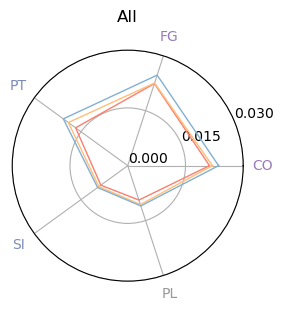

In [ ]:
# All fibers
ylim = 0.03
lm_lab = LM_LAB[0]
lr_res_tbl = merged_data[merged_data.lm == lm_lab][["Group", "pid", *[item[0] for item in CM_ARR[1:]]]]
lr_rsq_mean = get_rsq_mean(lr_res_tbl)
categories = list(lr_rsq_mean.columns)
N = len(categories)
angles = get_angles(N)
fig, ax = plt.subplots(figsize=(3, 3), subplot_kw={"polar": True})
plot_radar_for_tbl(lr_rsq_mean, "All", ylim, colors_hex, DISGROUPS, angles, ax)
plt.savefig(f"{output_dir}/global_CFC_dominance_comparison_rada_lm-all.svg", bbox_inches="tight")


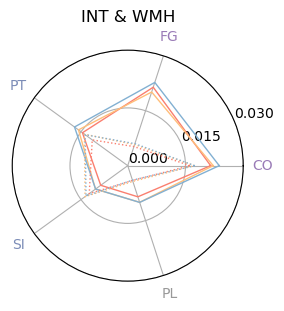

In [ ]:

# INT & WMH
fig, ax = plt.subplots(figsize=(3, 3), subplot_kw={"polar": True})
for lm_lab, linestyle in zip(LM_LAB[1:3], ["solid", ":"]):
    lr_res_tbl = merged_data[merged_data.lm == lm_lab][["Group", *[item[0] for item in CM_ARR[1:]]]]
    lr_rsq_mean = lr_res_tbl.groupby("Group").mean()
    plot_radar_for_tbl(lr_rsq_mean, "", ylim, colors_hex, DISGROUPS, get_angles(len(lr_rsq_mean.columns)), ax, linestyle)
ax.set_title("INT & WMH")
plt.savefig(f"{output_dir}/global_CFC_dominance_comparison_rada_lm-dec.svg", bbox_inches="tight")


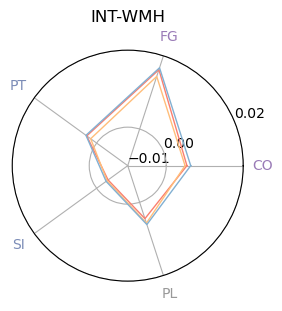

In [ ]:

# Difference
lr_res_tbl = merged_diff[["Group", "pid", *[item[0] for item in CM_ARR[1:]]]]
lr_rsq_mean = get_rsq_mean(lr_res_tbl)
categories = list(lr_rsq_mean.columns)
N = len(categories)
angles = get_angles(N)
fig, ax = plt.subplots(figsize=(3, 3), subplot_kw={"polar": True})
plot_radar_for_tbl(lr_rsq_mean, "INT-WMH", 0.02, colors_hex, DISGROUPS, angles, ax)
ax.set_yticks(np.round(np.linspace(-0.01, 0.02, 3), 2))
plt.savefig(f"{output_dir}/global_CFC_dominance_comparison_rada_lm-intwmh.svg", bbox_inches="tight")

In [ ]:
# int_wmh_tbl

In [ ]:

for cm_lab in CM_LAB_ARR:
    
    res = pg.mixed_anova(data=int_wmh_tbl, dv=cm_lab,subject= 'pid',within='lm', between='Group')
    # print(cm_lab, res)
    print(cm_lab, res[res.Source=='lm']['p-unc'],res[res.Source=='Interaction']['p-unc']   )

co-wei 1    6.417850e-50
Name: p-unc, dtype: float64 2    0.17019
Name: p-unc, dtype: float64
fg-wei 1    8.184095e-138
Name: p-unc, dtype: float64 2    0.060667
Name: p-unc, dtype: float64
pt-wei 1    0.000076
Name: p-unc, dtype: float64 2    0.730821
Name: p-unc, dtype: float64
si-wei 1    6.603802e-14
Name: p-unc, dtype: float64 2    0.814782
Name: p-unc, dtype: float64
pl-wei 1    2.428631e-37
Name: p-unc, dtype: float64 2    0.186281
Name: p-unc, dtype: float64


In [ ]:
int_wmh_tbl

,pid,Group,cm,idx,rsq,rsq_lrm,pval,co-wei,fg-wei,pt-wei,si-wei,pl-wei,lm
0,sub-286,NCI,lrm,0,0.050807,0,0,0.014884,0.014383,0.006166,0.010360,0.005014,int
1,sub-850,NCI,lrm,0,0.106790,0,0,0.023671,0.034819,0.029700,0.009062,0.009538,int
2,sub-763,aMCI,lrm,0,0.043256,0,0,0.014774,0.018384,0.003328,0.003011,0.003759,int
3,sub-375,NCI,lrm,0,0.091084,0,0,0.034391,0.030809,0.008561,0.007077,0.010246,int
4,sub-756,aMCI,lrm,0,0.107882,0,0,0.023208,0.030027,0.029596,0.010334,0.014717,int
...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,sub-716,NCI,lrm,0,0.053883,0,0,0.015223,0.007373,0.016091,0.011154,0.004041,wmh
710,sub-853,aMCI,lrm,0,0.029454,0,0,0.012410,0.003113,0.002432,0.010229,0.001270,wmh
711,sub-315,naMCI,lrm,0,0.050430,0,0,0.020019,0.005368,0.007578,0.014841,0.002623,wmh
712,sub-739,NCI,lrm,0,0.039460,0,0,0.014055,0.004056,0.013205,0.004672,0.003473,wmh
